In [ ]:
# Kepler

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
df = pd.read_csv('/Users/keatondiehl/python_decal_fa25/course_assignments/homework9/solar_system.csv')
df.shape
# 20 rows, 11 columns

(20, 11)

In [15]:
df

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
5,Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
6,Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
7,Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
8,Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
9,Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9


In [60]:
print(df.columns)

Index(['Mars', 'Jupiter', 'Saturn', 'Uranus', 'Neptune', 'Pluto'], dtype='object')


In [50]:
print(df.index)

Index(['0.073', '3475', '3340', '1.6', '2.4', '655.7', '708.7', '0.384',
       '0.363', '0.406', '27.3', '1.0', '5.1', '0.055', '6.7', '-20', '0', '0',
       'No', 'No'],
      dtype='object', name='Moon')


In [48]:
orbital_period = df.iloc[10, 1:].astype(float)   
perihelion     = df.iloc[8, 1:].astype(float)
aphelion       = df.iloc[9, 1:].astype(float)

Jupiter     740.6
Saturn     1357.6
Uranus     2732.7
Neptune    4471.1
Pluto      4436.8
Name: 0.363, dtype: float64


In [45]:
print(df.index)
print(df.columns)

Index(['0.073', '3475', '3340', '1.6', '2.4', '655.7', '708.7', '0.384',
       '0.363', '0.406', '27.3', '1.0', '5.1', '0.055', '6.7', '-20', '0', '0',
       'No', 'No'],
      dtype='object', name='Moon')
Index(['Mars', 'Jupiter', 'Saturn', 'Uranus', 'Neptune', 'Pluto'], dtype='object')


In [54]:
# Perihelion: Closest the orbiting object comes to the sun during its orbit
# Aphelion: Farthest the orbiting object goes from the sun during its orbit
# Semi-Major Axis: The "radius" of the orbit, or half the distance of the line drawn between aphelion and perihelion

In [55]:
semi_major_axis = (perihelion + aphelion) / 2 

In [64]:
new_row = pd.DataFrame([["Semi-Major Axis (10^6 km)", *semi_major_axis]], columns=df.columns)
df = pd.concat([df, new_row], ignore_index=True)

df.shape
# 24 rows, 6 columns

(24, 6)

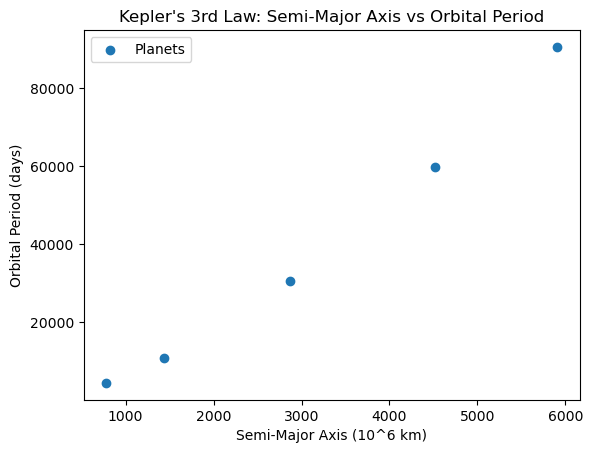

In [65]:
plt.figure()

plt.scatter(semi_major_axis, orbital_period, label="Planets")
plt.xlabel("Semi-Major Axis (10^6 km)")
plt.ylabel("Orbital Period (days)")
plt.title("Kepler's 3rd Law")
plt.legend()

plt.show()


In [67]:
def kepler_third_law(a, m):
    return m * a ** 1.5

In [68]:
popt, pcov = curve_fit(kepler_third_law, semi_major_axis, orbital_period)
m_fit = popt[0]

In [69]:
print(f"Fitted model: T = {m_fit:.2f} * a^1.5")

Fitted model: T = 0.20 * a^1.5


In [79]:
residuals = orbital_period - kepler_third_law(semi_major_axis, m_fit)
chi2 = np.sum(residuals ** 2)
dof = len(orbital_period) - 1 # -1 for single parameter
chi2_reduced = chi2 / dof
print(f"Reduced chi-squared: {chi2_reduced:.2f}")

Reduced chi-squared: 92684.45


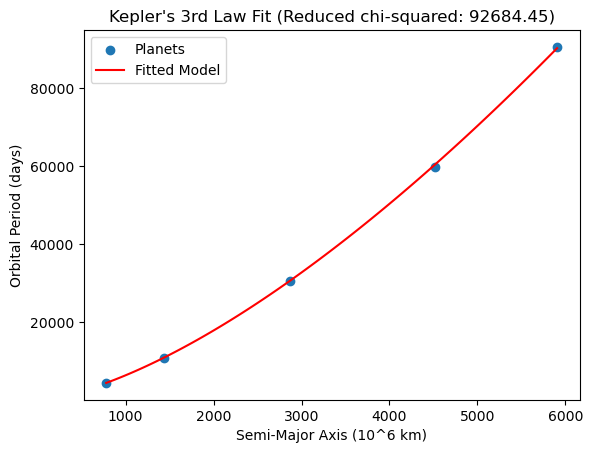

In [88]:
plt.figure()

plt.scatter(semi_major_axis, orbital_period, label="Planets")
plt.plot(a_vals, kepler_third_law(a_vals, m_fit), 'r-', label="Fitted Model")
plt.xlabel("Semi-Major Axis (10^6 km)")
plt.ylabel("Orbital Period (days)")
plt.title(f"Kepler's 3rd Law Fit (Reduced chi-squared: {chi2_reduced:.2f})")
plt.legend()

plt.show()

In [89]:
df.to_csv("kepler.csv", index=False)